# 1. Аудит одномерного исследовательского ряда

**Цели:** проверить схему, пропуски, масштаб и визуально отделить центр распределения от редких событий. Данные фиксированы; истинных меток экстремумов нет.

In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data/generated/fractal_extreme_series.csv").exists())
DATA = ROOT / "data/generated/fractal_extreme_series.csv"
SEED = 42
rng = np.random.default_rng(SEED)
df = pd.read_csv(DATA)
x = df["value"].to_numpy()
assert np.isfinite(x).all() and x.ndim == 1

summary = df.describe(percentiles=[.01,.05,.5,.95,.99]).T
summary


,count,mean,std,min,1%,5%,50%,95%,99%,max
timestamp,1500.0,749.500000,433.157015,0.00000,14.990000,74.95000,749.50000,1424.050000,1484.010000,1499.000000
value,1500.0,0.197333,1.505983,-3.13635,-2.316572,-1.73771,0.02248,2.106093,7.240074,9.223077
is_extreme,1500.0,0.050000,0.218018,0.00000,0.000000,0.00000,0.00000,0.050000,1.000000,1.000000


,count,mean,std,min,1%,5%,50%,95%,99%,max
timestamp,1500.0,749.500000,433.157015,0.00000,14.990000,74.95000,749.50000,1424.050000,1484.010000,1499.000000
value,1500.0,0.197333,1.505983,-3.13635,-2.316572,-1.73771,0.02248,2.106093,7.240074,9.223077
is_extreme,1500.0,0.050000,0.218018,0.00000,0.000000,0.00000,0.00000,0.050000,1.000000,1.000000


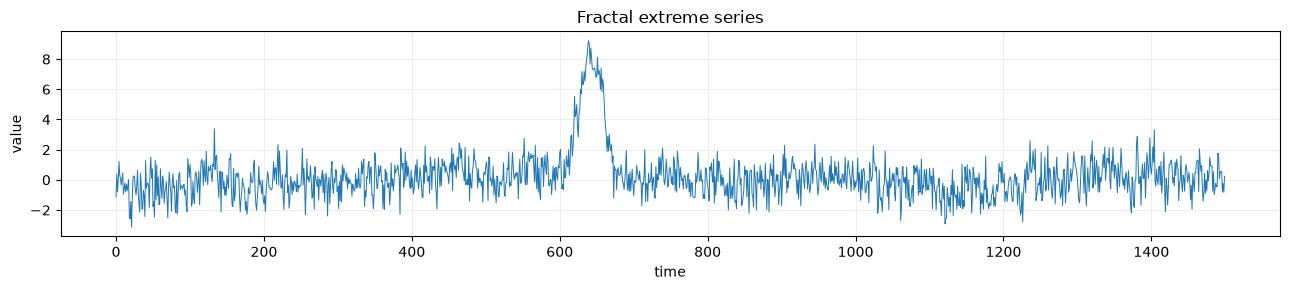

In [2]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(13, 3))
ax.plot(df.timestamp, x, lw=.7)
ax.set(title="Fractal extreme series", xlabel="time", ylabel="value")
ax.grid(alpha=.2); fig.tight_layout()
summary


Наблюдаемые пики — кандидаты, а не размеченная истина. Не выбирайте порог только по этой картинке.

**Самопроверка:** почему отсутствие пропусков не гарантирует качество? Что изменит стандартизация? Почему нельзя считать каждый высокий отсчёт независимым событием?